# Keyboard Dynamics avec Tappy Keystroke Data

Ce notebook teste la meme logique que la baseline NeuroQWERTY sur le dataset **Tappy Keystroke Data v1.0.0** de PhysioNet.

Difference importante: Tappy est beaucoup plus volumineux et collecte des frappes en conditions naturelles, sur plusieurs semaines/mois, mais les labels sont auto-declares et les donnees ne sont pas issues d'un protocole clinique encadre comme NeuroQWERTY.

Objectifs:
- reconstruire des features journalieres a partir des fichiers mensuels Tappy;
- faire une EDA orientee qualite, volumetrie et biais;
- appliquer une validation stricte par utilisateur (`user_key`);
- comparer les memes familles de modeles;
- tester Binary PSO pour selectionner un sous-ensemble de features;
- exporter un pipeline reutilisable pour une future application.

Source dataset: https://physionet.org/content/tappy/1.0.0/

## 1. Configuration

PhysioNet documente les colonnes des fichiers Tappy comme suit:

`UserKey`, `Date`, `Timestamp`, `Hand`, `Hold time`, `Direction`, `Latency time`, `Flight time`.

Les temps sont en millisecondes. Le notebook travaille volontairement avec des features clavier uniquement pour eviter d'apprendre directement des variables cliniques ou medicationnelles.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from pyswarms.discrete import BinaryPSO
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "data" / "tappy-keystroke-data-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent

TAPPY_ROOT = ROOT / "data" / "tappy-keystroke-data-1.0.0"
USER_DIR = TAPPY_ROOT / "Archived-users" / "Archived users"
DATA_DIR = TAPPY_ROOT / "Archived-Data" / "Tappy Data"
PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
PROCESSED_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

FEATURE_CACHE = PROCESSED_DIR / "tappy_daily_features.csv"
FORCE_REBUILD = False

print(f"Project root: {ROOT}")
print(f"Tappy root exists: {TAPPY_ROOT.exists()} -> {TAPPY_ROOT}")
print(f"Raw user files: {len(list(USER_DIR.glob('User_*.txt')))}")
print(f"Raw monthly data files: {len(list(DATA_DIR.glob('*.txt')))}")

Project root: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection
Tappy root exists: True -> /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/data/tappy-keystroke-data-1.0.0
Raw user files: 227
Raw monthly data files: 622


## 2. Chargement des metadonnees utilisateurs

Chaque fichier utilisateur contient un identifiant anonyme et des champs auto-declares: annee de naissance, genre, Parkinson, tremors, annee de diagnostic, UPDRS si connu, impact, traitements, etc.

Pour la modelisation, on utilise seulement `Parkinsons` comme label. Les autres champs servent a comprendre les biais potentiels du dataset.

In [2]:
def parse_user_file(path: Path) -> dict:
    row = {"user_key": path.stem.replace("User_", "")}
    for line in path.read_text(errors="ignore").splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            row[key.strip()] = value.strip()
    return row

users = pd.DataFrame(parse_user_file(path) for path in sorted(USER_DIR.glob("User_*.txt")))
users["label"] = users["Parkinsons"].map({"False": 0, "True": 1})
users["birth_year"] = pd.to_numeric(users["BirthYear"], errors="coerce")

print(f"Users metadata rows: {len(users)}")
display(users["Parkinsons"].value_counts(dropna=False).rename("n_users"))
display(users.head())

Users metadata rows: 227


Parkinsons
True     169
False     58
Name: n_users, dtype: int64

,user_key,BirthYear,Gender,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other,label,birth_year
0,0EA27ICBLF,1952,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False,1,1952.0
1,0QAZFRHQHW,1959,Female,False,False,------,None,Don't know,------,False,False,False,False,0,1959.0
2,0WTDIGPSBZ,1946,Female,False,False,------,None,Don't know,------,False,False,False,False,0,1946.0
3,1HOEBIGASW,1944,Male,False,False,------,None,Don't know,------,False,False,False,False,0,1944.0
4,1WMVCCU4RH,1953,Male,True,True,2017,Left,Don't know,Medium,False,False,False,False,1,1953.0


### Lecture des metadonnees

Le dataset contient **227 utilisateurs** dans les metadonnees: **169 Parkinson** et **58 controles**. Le desequilibre est donc deja fort au niveau utilisateur, avec environ trois fois plus de participants Parkinson que controle.

C'est un point methodologique majeur pour Tappy. Une accuracy elevee ou un bon F1 binaire peut etre trompeur si le modele predit surtout la classe Parkinson. Pour cette raison, la suite du notebook utilise aussi `balanced_accuracy` et `f1_macro`, qui donnent du poids aux deux classes.

Les labels sont auto-declares. Tappy apporte du volume et une frappe en conditions naturelles, mais la certitude clinique du label est plus faible que dans NeuroQWERTY.

## 3. Feature engineering journalier

Les fichiers Tappy sont mensuels. Pour augmenter le nombre d'observations tout en gardant une unite interpretable, on agrege les frappes par `user_key` et `date`.

Le seuil `MIN_KEYSTROKES_PER_DAY = 50` retire les journees trop courtes pour donner des statistiques stables. La validation reste groupee par utilisateur, donc plusieurs jours d'un meme utilisateur ne peuvent jamais se retrouver a la fois dans train et validation.

In [3]:
RAW_COLUMNS = [
    "user_key", "date", "timestamp", "hand", "hold_time_ms", "direction", "latency_time_ms", "flight_time_ms"
]

MIN_KEYSTROKES_PER_DAY = 50


def q10(series):
    return series.quantile(0.10)


def q90(series):
    return series.quantile(0.90)


def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)


def load_tappy_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=RAW_COLUMNS,
        usecols=range(8),
        dtype=str,
        engine="python",
    )
    for col in ["hold_time_ms", "latency_time_ms", "flight_time_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["date"] = pd.to_numeric(df["date"], errors="coerce")
    df = df.dropna(subset=["user_key", "date", "hold_time_ms", "latency_time_ms", "flight_time_ms"])
    df["date"] = df["date"].astype(int).astype(str).str.zfill(6)
    return df


def clean_tappy_keystrokes(df: pd.DataFrame) -> pd.DataFrame:
    clean = df.copy()
    clean = clean[clean["hold_time_ms"].between(20, 1000)]
    clean = clean[clean["latency_time_ms"].between(0, 5000)]
    clean = clean[clean["flight_time_ms"].between(-1000, 5000)]
    clean = clean[clean["hand"].isin(["L", "R", "S"])]
    clean = clean[clean["direction"].isin(["LL", "LR", "RL", "RR", "LS", "SL", "RS", "SR", "SS"])]
    return clean


def aggregate_daily_features(raw_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(raw_dir.glob("*.txt")):
        raw = load_tappy_file(path)
        clean = clean_tappy_keystrokes(raw)
        if clean.empty:
            continue

        grouped = clean.groupby(["user_key", "date"])
        agg = grouped.agg(
            n_keystrokes=("hold_time_ms", "size"),
            mean_hold_time=("hold_time_ms", "mean"),
            std_hold_time=("hold_time_ms", "std"),
            median_hold_time=("hold_time_ms", "median"),
            iqr_hold_time=("hold_time_ms", iqr),
            q10_hold_time=("hold_time_ms", q10),
            q90_hold_time=("hold_time_ms", q90),
            mean_latency_time=("latency_time_ms", "mean"),
            std_latency_time=("latency_time_ms", "std"),
            median_latency_time=("latency_time_ms", "median"),
            iqr_latency_time=("latency_time_ms", iqr),
            q90_latency_time=("latency_time_ms", q90),
            mean_flight_time=("flight_time_ms", "mean"),
            std_flight_time=("flight_time_ms", "std"),
            median_flight_time=("flight_time_ms", "median"),
            iqr_flight_time=("flight_time_ms", iqr),
            q90_flight_time=("flight_time_ms", q90),
        ).reset_index()

        for value in ["L", "R", "S"]:
            prop = clean["hand"].eq(value).groupby([clean["user_key"], clean["date"]]).mean()
            agg = agg.merge(prop.rename(f"prop_hand_{value}").reset_index(), on=["user_key", "date"], how="left")

        for value in ["LL", "LR", "RL", "RR"]:
            prop = clean["direction"].eq(value).groupby([clean["user_key"], clean["date"]]).mean()
            agg = agg.merge(prop.rename(f"prop_direction_{value}").reset_index(), on=["user_key", "date"], how="left")

        rows.append(agg)

    daily = pd.concat(rows, ignore_index=True)
    daily = daily[daily["n_keystrokes"] >= MIN_KEYSTROKES_PER_DAY].reset_index(drop=True)
    return daily

if FEATURE_CACHE.exists() and not FORCE_REBUILD:
    daily_features = pd.read_csv(FEATURE_CACHE)
    print(f"Loaded cached features: {FEATURE_CACHE}")
else:
    daily_features = aggregate_daily_features(DATA_DIR)
    daily_features.to_csv(FEATURE_CACHE, index=False)
    print(f"Saved cached features: {FEATURE_CACHE}")

tappy = daily_features.merge(
    users[["user_key", "label", "Parkinsons", "Gender", "birth_year", "Tremors", "Impact"]],
    on="user_key",
    how="inner",
)

# Approximate age at record date: dates are YYMMDD and all years are 20xx/2016-2017 in this dataset.
tappy["record_year"] = 2000 + tappy["date"].astype(str).str.slice(0, 2).astype(int)
tappy["age_at_recording"] = tappy["record_year"] - tappy["birth_year"]

print(f"Daily rows after filtering: {len(tappy)}")
print(f"Users with usable data: {tappy['user_key'].nunique()}")
display(tappy.groupby("label").agg(days=("label", "size"), users=("user_key", "nunique")))
display(tappy.head())

Loaded cached features: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/data/processed/tappy_daily_features.csv
Daily rows after filtering: 6235
Users with usable data: 196


,days,users
label,,
0,1452,49
1,4783,147


,user_key,date,n_keystrokes,mean_hold_time,std_hold_time,median_hold_time,iqr_hold_time,q10_hold_time,q90_hold_time,mean_latency_time,...,prop_direction_RL,prop_direction_RR,label,Parkinsons,Gender,birth_year,Tremors,Impact,record_year,age_at_recording
0,0EA27ICBLF,160722,2650,87.219925,23.542432,85.9,31.3,62.5,117.2,274.440491,...,0.136604,0.183396,1,True,Female,1952.0,True,Severe,2016,64.0
1,0EA27ICBLF,160724,1986,84.846526,26.067446,78.1,31.3,58.6,121.1,294.454582,...,0.186304,0.188318,1,True,Female,1952.0,True,Severe,2016,64.0
2,0EA27ICBLF,160726,29988,87.081993,23.322502,85.9,31.3,62.5,117.2,284.933373,...,0.155262,0.192877,1,True,Female,1952.0,True,Severe,2016,64.0
3,0EA27ICBLF,160727,22260,88.158491,25.046876,85.9,31.3,62.5,121.1,287.335741,...,0.145553,0.192992,1,True,Female,1952.0,True,Severe,2016,64.0
4,0EA27ICBLF,160728,45336,85.055294,22.664583,82.0,27.4,58.6,117.2,287.368846,...,0.153785,0.214134,1,True,Female,1952.0,True,Severe,2016,64.0


### Lecture de l'agregation journaliere

Apres nettoyage et seuil minimum de 50 frappes par jour, on obtient **6235 jours exploitables** pour **196 utilisateurs**. La repartition reste desequilibree: **4783 jours Parkinson** pour **1452 jours controle**, provenant de **147 utilisateurs Parkinson** et **49 controles**.

Cette representation est beaucoup plus riche que NeuroQWERTY en nombre de lignes, mais les lignes ne sont pas independantes: plusieurs jours viennent du meme utilisateur. Le groupement par `user_key` dans la validation est donc non negociable.

On voit aussi des volumes journaliers tres variables. Certains jours ont quelques dizaines de frappes, d'autres plusieurs dizaines de milliers. Cela reflete une collecte passive reelle, mais introduit un biais d'usage informatique que le modele peut exploiter.

## 4. EDA

On regarde a la fois les classes, le volume par utilisateur, les distributions de features et les correlations avec le label. Les variables d'age et de metadonnees sont analysees mais non utilisees par les modeles clavier.

2026-05-06 17:02:46,068 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,070 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,079 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,081 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


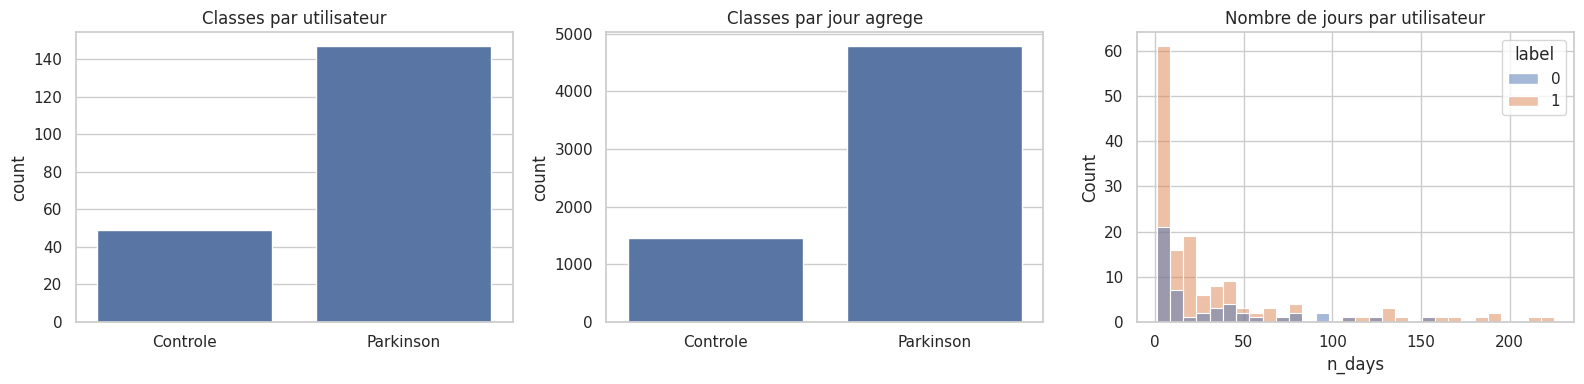

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=tappy.drop_duplicates("user_key"), x="label", ax=axes[0])
axes[0].set_title("Classes par utilisateur")
axes[0].set_xticklabels(["Controle", "Parkinson"])
axes[0].set_xlabel("")

sns.countplot(data=tappy, x="label", ax=axes[1])
axes[1].set_title("Classes par jour agrege")
axes[1].set_xticklabels(["Controle", "Parkinson"])
axes[1].set_xlabel("")

user_days = tappy.groupby(["user_key", "label"]).size().rename("n_days").reset_index()
sns.histplot(data=user_days, x="n_days", hue="label", bins=30, ax=axes[2])
axes[2].set_title("Nombre de jours par utilisateur")
plt.tight_layout()
plt.show()

### Lecture de la volumetrie

Les figures confirment le desequilibre vu dans les tableaux: la classe Parkinson domine a la fois en nombre d'utilisateurs et en nombre de jours. Le troisieme graphique montre aussi une forte heterogeneite du nombre de jours par utilisateur.

Cette heterogeneite est utile pour capter des patterns longitudinaux, mais elle complique l'evaluation. Un utilisateur tres actif peut influencer davantage le modele qu'un utilisateur peu actif. La validation groupee evite la fuite entre train et test, mais elle ne supprime pas entierement ce biais de contribution.

In [5]:
feature_cols = [
    "n_keystrokes",
    "mean_hold_time", "std_hold_time", "median_hold_time", "iqr_hold_time", "q10_hold_time", "q90_hold_time",
    "mean_latency_time", "std_latency_time", "median_latency_time", "iqr_latency_time", "q90_latency_time",
    "mean_flight_time", "std_flight_time", "median_flight_time", "iqr_flight_time", "q90_flight_time",
    "prop_hand_L", "prop_hand_R", "prop_hand_S",
    "prop_direction_LL", "prop_direction_LR", "prop_direction_RL", "prop_direction_RR",
]

summary = tappy[feature_cols].describe().T
summary["missing"] = tappy[feature_cols].isna().sum()
display(summary)

,count,mean,std,min,25%,50%,75%,max,missing
n_keystrokes,6235.0,1402.332157,2777.141138,50.000000,190.000000,579.000000,1595.000000,59039.000000,0
mean_hold_time,6235.0,123.097793,34.699798,51.026754,98.580259,115.742915,144.550904,293.075261,0
std_hold_time,6235.0,42.120262,20.693321,9.003179,27.187600,39.407706,51.739908,184.530882,0
median_hold_time,6235.0,120.029479,34.489192,46.900000,93.800000,113.300000,140.600000,289.100000,0
iqr_hold_time,6235.0,51.196560,28.310748,2.000000,31.300000,46.900000,62.500000,287.100000,0
q10_hold_time,6235.0,73.281219,24.739525,23.400000,56.600000,67.900000,85.900000,183.600000,0
q90_hold_time,6235.0,175.528611,57.609979,62.500000,136.700000,164.100000,210.900000,496.100000,0
mean_latency_time,6235.0,301.479867,96.042971,131.908517,233.566374,284.285706,344.683867,718.981481,0
std_latency_time,6235.0,115.556584,31.457628,52.301081,92.116910,103.808725,140.325066,270.625119,0
median_latency_time,6235.0,286.355237,102.061143,97.700000,218.800000,269.500000,335.900000,734.400000,0


### Lecture des statistiques descriptives

Les temps sont en millisecondes. Les moyennes observees sont plausibles: `mean_hold_time` autour de **123 ms**, `mean_latency_time` autour de **301 ms**, et `mean_flight_time` autour de **211 ms**.

Le volume journalier est tres disperse: mediane a **579 frappes**, moyenne a **1402**, maximum a plus de **59000**. Cette asymetrie indique que le dataset melange des journees de frappe tres courtes et des journees d'utilisation intensive.

Les variables de timing n'ont pas de valeurs manquantes apres nettoyage. C'est propre pour la modelisation, mais il ne faut pas oublier que cette proprete vient d'un filtrage assez strict des valeurs aberrantes.

2026-05-06 17:02:46,279 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,282 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,292 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,295 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,305 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-05-06 17:02:46,320 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,330 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,332 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,341 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 17:02:46,344 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


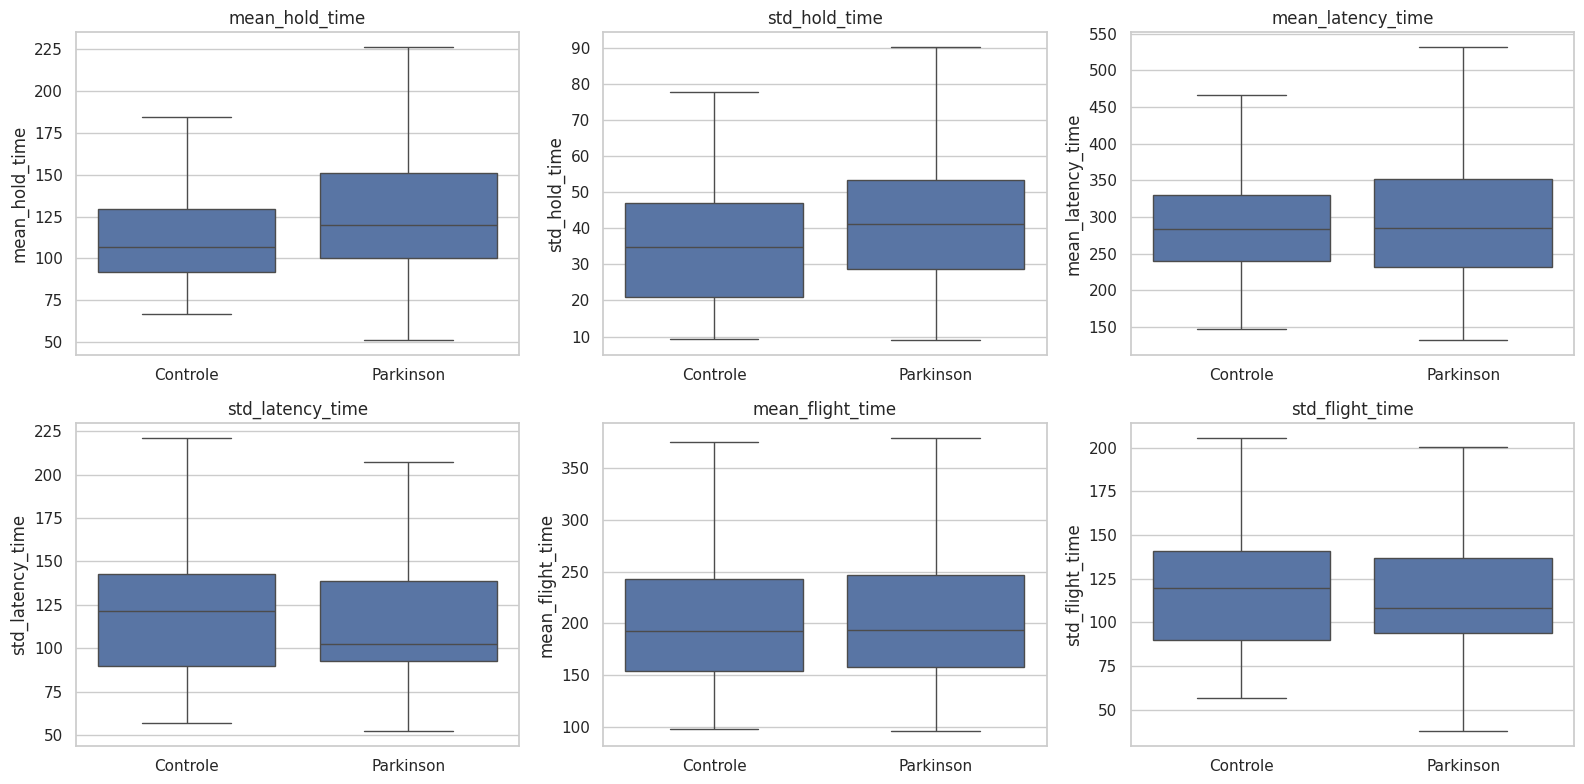

In [6]:
plot_features = [
    "mean_hold_time", "std_hold_time", "mean_latency_time", "std_latency_time", "mean_flight_time", "std_flight_time",
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), plot_features):
    sns.boxplot(data=tappy, x="label", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xticklabels(["Controle", "Parkinson"])
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Lecture des boxplots

Les boxplots montrent un chevauchement net entre controles et Parkinson. On ne voit pas de seuil simple qui separerait les deux groupes sur une seule variable. C'est coherent avec une collecte naturelle: les pauses, le type de texte, l'application utilisee et le niveau de fatigue ajoutent beaucoup de variance.

Le signal semble un peu plus visible sur les features de hold time que sur les variables latency/flight. C'est aussi ce que confirmera la correlation: les features de maintien des touches portent le signal lineaire le plus clair, meme s'il reste modeste.

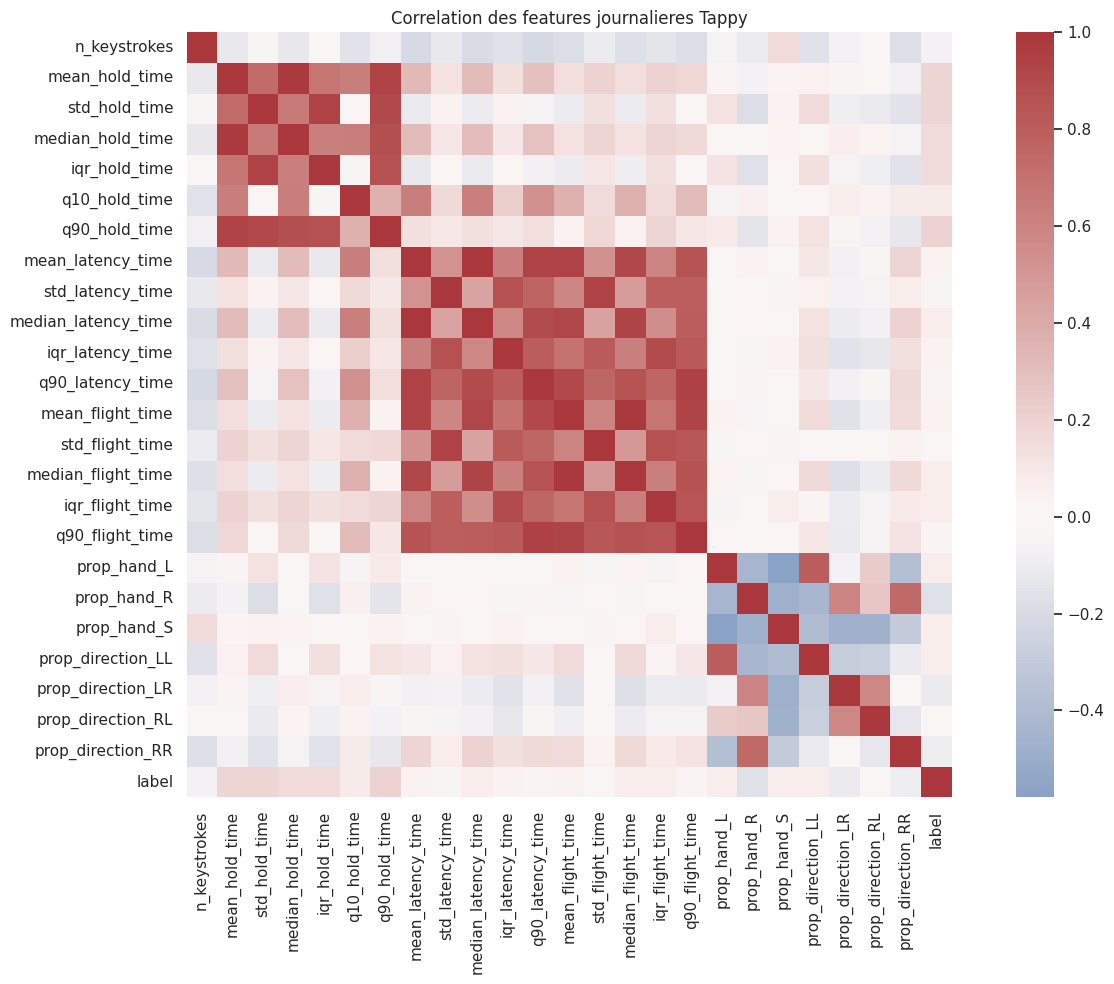

,correlation_with_label
q90_hold_time,0.202268
std_hold_time,0.191323
mean_hold_time,0.186340
prop_hand_R,-0.167429
median_hold_time,0.162038
iqr_hold_time,0.160309
prop_direction_LR,-0.114472
prop_direction_RR,-0.097847
q10_hold_time,0.083450
prop_direction_LL,0.078848


In [7]:
corr = tappy[feature_cols + ["label"]].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="vlag", center=0, square=True)
plt.title("Correlation des features journalieres Tappy")
plt.tight_layout()
plt.show()

label_corr = corr["label"].drop("label").sort_values(key=lambda s: s.abs(), ascending=False)
display(label_corr.to_frame("correlation_with_label").head(15))

### Lecture des correlations

Les correlations avec le label sont faibles a moderees. Les plus fortes sont `q90_hold_time` (**0.20**), `std_hold_time` (**0.19**), `mean_hold_time` (**0.19**) et `median_hold_time` (**0.16**). Cela indique un signal dans les temps de maintien, mais rien d'aussi separable qu'un biomarqueur clinique direct.

Certaines proportions de mains/directions sont aussi correlees, par exemple `prop_hand_R` autour de **-0.17**. Ces variables peuvent aider la prediction, mais elles sont moins directement interpretable comme symptome moteur: elles peuvent refleter la maniere d'utiliser le clavier, le type de texte ou le contexte applicatif.

Conclusion EDA: Tappy contient plus de signal longitudinal que NeuroQWERTY, mais aussi plus de bruit et de biais comportemental.

## 5. Validation groupee et modeles

Tous les folds sont groupes par `user_key`. Cela signifie qu'un utilisateur entier est reserve a la validation dans chaque fold, avec tous ses jours. Cette contrainte est indispensable pour eviter que le modele reconnaisse indirectement un individu deja vu.

In [8]:
X = tappy[feature_cols].copy()
y = tappy["label"].astype(int).copy()
groups = tappy["user_key"].astype(str).copy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), start=1):
    train_users = set(groups.iloc[train_idx])
    valid_users = set(groups.iloc[valid_idx])
    overlap = train_users & valid_users
    print(
        f"Fold {fold}: train_rows={len(train_idx)}, valid_rows={len(valid_idx)}, "
        f"train_users={len(train_users)}, valid_users={len(valid_users)}, user_overlap={len(overlap)}"
    )
    assert not overlap

numeric_preprocess = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]


def make_pipeline(model, use_smote=True):
    steps = numeric_preprocess.copy()
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)))
    steps.append(("model", model))
    return ImbPipeline(steps)

models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "SVC": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

models["VotingClassifier"] = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ("svc", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    voting="soft",
    n_jobs=-1,
)

models["StackingClassifier"] = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ("svc", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    stack_method="predict_proba",
    n_jobs=-1,
)

Fold 1: train_rows=4988, valid_rows=1247, train_users=156, valid_users=40, user_overlap=0
Fold 2: train_rows=4988, valid_rows=1247, train_users=156, valid_users=40, user_overlap=0
Fold 3: train_rows=4988, valid_rows=1247, train_users=158, valid_users=38, user_overlap=0
Fold 4: train_rows=4988, valid_rows=1247, train_users=157, valid_users=39, user_overlap=0
Fold 5: train_rows=4988, valid_rows=1247, train_users=157, valid_users=39, user_overlap=0


In [9]:
def evaluate_pipeline(name, pipeline, X_data, y_data, groups_data):
    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "f1_macro": "f1_macro",
    }
    scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        groups=groups_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    return row

baseline_results = []
for name, model in models.items():
    pipeline = make_pipeline(model, use_smote=(name != "Dummy"))
    baseline_results.append(evaluate_pipeline(name, pipeline, X, y, groups))

results_df = pd.DataFrame(baseline_results).sort_values("f1_macro_mean", ascending=False)
display(results_df)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f1_macro_mean,f1_macro_std
1,LogisticRegression,0.599679,0.114209,0.569707,0.085452,0.801909,0.048798,0.625723,0.144675,0.696930,0.111388,0.540572,0.093694
4,VotingClassifier,0.656616,0.085121,0.534601,0.097950,0.783696,0.053238,0.762866,0.098993,0.770515,0.067623,0.529566,0.088178
2,SVC,0.619727,0.088961,0.524245,0.099588,0.779437,0.058784,0.702860,0.102415,0.736172,0.073029,0.516235,0.085243
3,RandomForest,0.670730,0.087198,0.498958,0.098758,0.765485,0.046339,0.820379,0.091327,0.790654,0.064681,0.494289,0.102206
5,StackingClassifier,0.723336,0.043876,0.490374,0.049213,0.763152,0.019215,0.926399,0.042759,0.836724,0.028215,0.460973,0.063634
0,Dummy,0.767121,0.000393,0.500000,0.000000,0.767121,0.000393,1.000000,0.000000,0.868216,0.000252,0.434108,0.000126


### Lecture des resultats sans PSO

Le `DummyClassifier` obtient **0.77 d'accuracy** et **0.87 de F1 binaire**, uniquement parce qu'il predit toujours Parkinson. Sa `balanced_accuracy` reste a **0.50** et son `f1_macro` a **0.43**, ce qui montre qu'il ne detecte pas les controles.

Sans PSO, le meilleur modele selon `f1_macro` est `LogisticRegression` avec environ **0.54**. Les modeles d'ensemble ont parfois une meilleure accuracy ou un meilleur recall Parkinson, mais ils restent faibles sur l'equilibre des deux classes.

C'est un bon exemple de piege sur dataset medical desequilibre: la metrique principale doit penaliser l'abandon de la classe minoritaire.

## 6. Selection de features avec Binary PSO

On applique PSO sur les features journalieres clavier. La fitness maximise le F1 macro moyen en validation groupee, avec une petite penalite sur le nombre de features selectionnees. Le F1 macro est utilise parce que Tappy est fortement desequilibre.

In [10]:
PSO_BASE_MODEL = RandomForestClassifier(
    n_estimators=180,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


def pso_objective(masks: np.ndarray) -> np.ndarray:
    costs = []
    n_features = len(feature_cols)
    for mask in masks:
        selected = [col for col, keep in zip(feature_cols, mask.astype(bool)) if keep]
        if not selected:
            costs.append(1.0)
            continue
        pipeline = make_pipeline(clone(PSO_BASE_MODEL), use_smote=True)
        scores = cross_validate(
            pipeline,
            X[selected],
            y,
            groups=groups,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1,
            error_score="raise",
        )["test_score"]
        penalty = 0.02 * (len(selected) / n_features)
        costs.append((1.0 - scores.mean()) + penalty)
    return np.array(costs)

optimizer = BinaryPSO(
    n_particles=10,
    dimensions=len(feature_cols),
    options={"c1": 1.5, "c2": 1.5, "w": 0.8, "k": 5, "p": 2},
)

best_cost, best_mask = optimizer.optimize(pso_objective, iters=10, verbose=True)
selected_features = [col for col, keep in zip(feature_cols, best_mask.astype(bool)) if keep]
print(f"Best cost: {best_cost:.4f}")
print(f"Selected {len(selected_features)} / {len(feature_cols)} features:")
print(selected_features)

2026-05-06 17:03:14,493 - pyswarms.discrete.binary - INFO - Optimize for 10 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8, 'k': 5, 'p': 2}


pyswarms.discrete.binary:   0%|          |0/10

pyswarms.discrete.binary:   0%|          |0/10, best_cost=0.451

pyswarms.discrete.binary:  10%|█         |1/10, best_cost=0.451

pyswarms.discrete.binary:  10%|█         |1/10, best_cost=0.451

...

pyswarms.discrete.binary:  90%|█████████ |9/10, best_cost=0.441

pyswarms.discrete.binary: 100%|██████████|10/10, best_cost=0.441

pyswarms.discrete.binary: 100%|██████████|10/10, best_cost=0.441


2026-05-06 17:04:32,366 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.44134808427623223, best pos: [0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1]


Best cost: 0.4413
Selected 8 / 24 features:
['median_hold_time', 'iqr_hold_time', 'q10_hold_time', 'q90_hold_time', 'median_flight_time', 'prop_hand_R', 'prop_hand_S', 'prop_direction_RR']


### Lecture de la selection PSO

PSO retient **8 features sur 24**: `median_hold_time`, `iqr_hold_time`, `q10_hold_time`, `q90_hold_time`, `median_flight_time`, `prop_hand_R`, `prop_hand_S`, `prop_direction_RR`.

La selection est coherente avec l'EDA: quatre variables de hold time sont conservees, ce qui confirme que le maintien des touches est le signal le plus stable. PSO ajoute aussi une feature de flight time et trois proportions de main/direction.

Ces proportions peuvent ameliorer la performance sur Tappy, mais elles demandent prudence pour une future app. Dans un test standardise, on voudra verifier si elles restent utiles ou si elles capturaient surtout des habitudes d'utilisation non liees a Parkinson.

In [11]:
pso_results = []
for name, model in models.items():
    pipeline = make_pipeline(model, use_smote=(name != "Dummy"))
    pso_results.append(evaluate_pipeline(f"{name} + PSO", pipeline, X[selected_features], y, groups))

all_results = pd.concat([results_df, pd.DataFrame(pso_results)], ignore_index=True)
all_results = all_results.sort_values("f1_macro_mean", ascending=False)
display(all_results)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f1_macro_mean,f1_macro_std
10,VotingClassifier + PSO,0.668324,0.099611,0.595238,0.065859,0.813767,0.031614,0.731936,0.141623,0.764476,0.094559,0.580309,0.077199
8,SVC + PSO,0.641540,0.097370,0.589077,0.063700,0.812125,0.032886,0.687199,0.131721,0.739263,0.095126,0.568106,0.075796
9,RandomForest + PSO,0.696552,0.087156,0.560403,0.085727,0.792785,0.038062,0.815163,0.099197,0.802037,0.066675,0.563117,0.093782
0,LogisticRegression,0.599679,0.114209,0.569707,0.085452,0.801909,0.048798,0.625723,0.144675,0.696930,0.111388,0.540572,0.093694
1,VotingClassifier,0.656616,0.085121,0.534601,0.097950,0.783696,0.053238,0.762866,0.098993,0.770515,0.067623,0.529566,0.088178
11,StackingClassifier + PSO,0.719487,0.066125,0.530053,0.074739,0.778833,0.030428,0.884584,0.065624,0.827840,0.044390,0.527925,0.090597
2,SVC,0.619727,0.088961,0.524245,0.099588,0.779437,0.058784,0.702860,0.102415,0.736172,0.073029,0.516235,0.085243
7,LogisticRegression + PSO,0.536808,0.117426,0.554216,0.097191,0.799178,0.078092,0.521592,0.161544,0.619760,0.136342,0.495696,0.096517
3,RandomForest,0.670730,0.087198,0.498958,0.098758,0.765485,0.046339,0.820379,0.091327,0.790654,0.064681,0.494289,0.102206
4,StackingClassifier,0.723336,0.043876,0.490374,0.049213,0.763152,0.019215,0.926399,0.042759,0.836724,0.028215,0.460973,0.063634


### Effet de PSO

Avec PSO, le meilleur modele devient `VotingClassifier + PSO`, avec environ **0.58 de F1 macro** et **0.60 de balanced accuracy**. C'est un gain net par rapport au meilleur modele sans PSO, qui etait autour de **0.54 de F1 macro**.

Le gain est modeste mais important: il montre que la selection reduit du bruit et aide a mieux traiter la classe controle. Les scores restent loin d'une performance clinique forte, mais ils sont plus credibles que l'accuracy du dummy.

On observe aussi que `RandomForest + PSO` a un F1 binaire plus eleve, mais un F1 macro plus faible. Le choix de `VotingClassifier + PSO` est donc justifie par l'objectif d'equilibre entre classes.

## 7. Matrice de confusion et export

Le meilleur modele est choisi par F1 macro moyen. On calcule ensuite des predictions out-of-fold pour obtenir une matrice de confusion plus lisible.

Best model: VotingClassifier + PSO
Features: ['median_hold_time', 'iqr_hold_time', 'q10_hold_time', 'q90_hold_time', 'median_flight_time', 'prop_hand_R', 'prop_hand_S', 'prop_direction_RR']
              precision    recall  f1-score   support

    Controle       0.34      0.46      0.39      1452
   Parkinson       0.82      0.73      0.77      4783

    accuracy                           0.67      6235
   macro avg       0.58      0.60      0.58      6235
weighted avg       0.71      0.67      0.68      6235



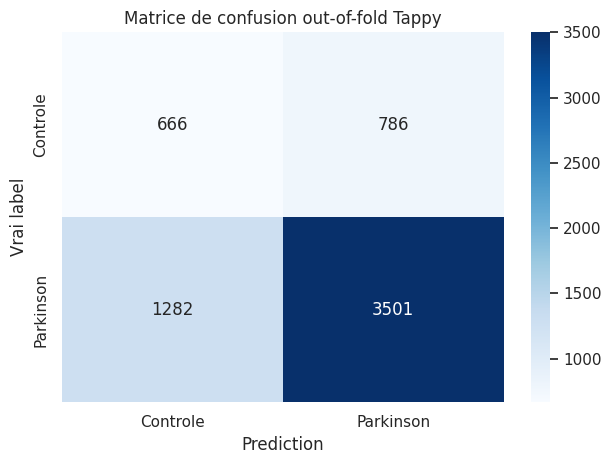

In [12]:
def out_of_fold_predictions(model, X_data, y_data, groups_data, use_smote=True):
    preds = np.zeros(len(y_data), dtype=int)
    for train_idx, valid_idx in cv.split(X_data, y_data, groups_data):
        pipeline = make_pipeline(clone(model), use_smote=use_smote)
        pipeline.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
        preds[valid_idx] = pipeline.predict(X_data.iloc[valid_idx])
    return preds

best_row = all_results.iloc[0]
best_name = best_row["model"]
uses_pso = best_name.endswith(" + PSO")
base_name = best_name.replace(" + PSO", "")
best_model = models[base_name]
best_features = selected_features if uses_pso else feature_cols
best_use_smote = base_name != "Dummy"

preds = out_of_fold_predictions(best_model, X[best_features], y, groups, use_smote=best_use_smote)
cm = confusion_matrix(y, preds)

print(f"Best model: {best_name}")
print(f"Features: {best_features}")
print(classification_report(y, preds, target_names=["Controle", "Parkinson"]))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Controle", "Parkinson"], yticklabels=["Controle", "Parkinson"])
plt.title("Matrice de confusion out-of-fold Tappy")
plt.xlabel("Prediction")
plt.ylabel("Vrai label")
plt.tight_layout()
plt.show()

### Lecture de la matrice de confusion

Le meilleur modele final est `VotingClassifier + PSO`. En predictions out-of-fold, il obtient:

- controle: precision **0.34**, recall **0.46**, F1 **0.39**;
- Parkinson: precision **0.82**, recall **0.73**, F1 **0.77**;
- accuracy globale **0.67**;
- macro F1 **0.58**.

Le modele detecte mieux Parkinson que les controles, ce qui est attendu avec ce desequilibre. Le recall controle a **0.46** montre qu'il produit encore beaucoup de faux positifs Parkinson. Pour un outil de prevention, cela peut etre acceptable comme premier filtre exploratoire, mais pas comme resultat final affiche sans nuance.

La bonne lecture est donc: Tappy permet d'apprendre un signal au-dessus du hasard equilibre, mais la qualite label/bruit/contexte limite fortement l'interpretabilite.

In [13]:
final_pipeline = make_pipeline(clone(best_model), use_smote=best_use_smote)
final_pipeline.fit(X[best_features], y)

artifact = {
    "pipeline": final_pipeline,
    "features": best_features,
    "model_name": best_name,
    "label_mapping": {0: "Controle", 1: "Parkinson"},
    "dataset": "Tappy Keystroke Data v1.0.0",
    "aggregation": "daily rows grouped by user_key/date; validation grouped by user_key",
}

model_path = MODEL_DIR / "keyboard_dynamics_tappy_pipeline.joblib"
joblib.dump(artifact, model_path)
print(f"Saved model artifact: {model_path}")

Saved model artifact: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/models/keyboard_dynamics_tappy_pipeline.joblib


## 8. Limites et prochaines etapes

Limites observees:
- labels auto-declares, moins rigoureux que NeuroQWERTY;
- collecte non supervisee, donc beaucoup de bruit de contexte;
- fort desequilibre: 147 utilisateurs Parkinson utilisables contre 49 controles;
- plusieurs jours par utilisateur, donc validation groupee obligatoire;
- accuracy et F1 binaire trompeurs: le dummy atteint 0.77 d'accuracy en predisant toujours Parkinson;
- performance equilibree encore modeste: meilleur macro F1 autour de 0.58;
- features de main/direction potentiellement liees aux habitudes de frappe plutot qu'a la maladie.

Prochaines etapes:
- comparer NeuroQWERTY vs Tappy dans un tableau commun avec les memes metriques;
- tester une agregation par utilisateur entier en plus de l'agregation journaliere;
- essayer une evaluation avec sous-echantillonnage par utilisateur pour limiter le poids des utilisateurs tres actifs;
- standardiser un protocole de frappe court pour la future interface web;
- extraire le feature engineering dans un module Python partage entre notebooks et app;
- tester un seuil de decision ajuste pour privilegier recall Parkinson ou reduction des faux positifs selon l'usage demo.